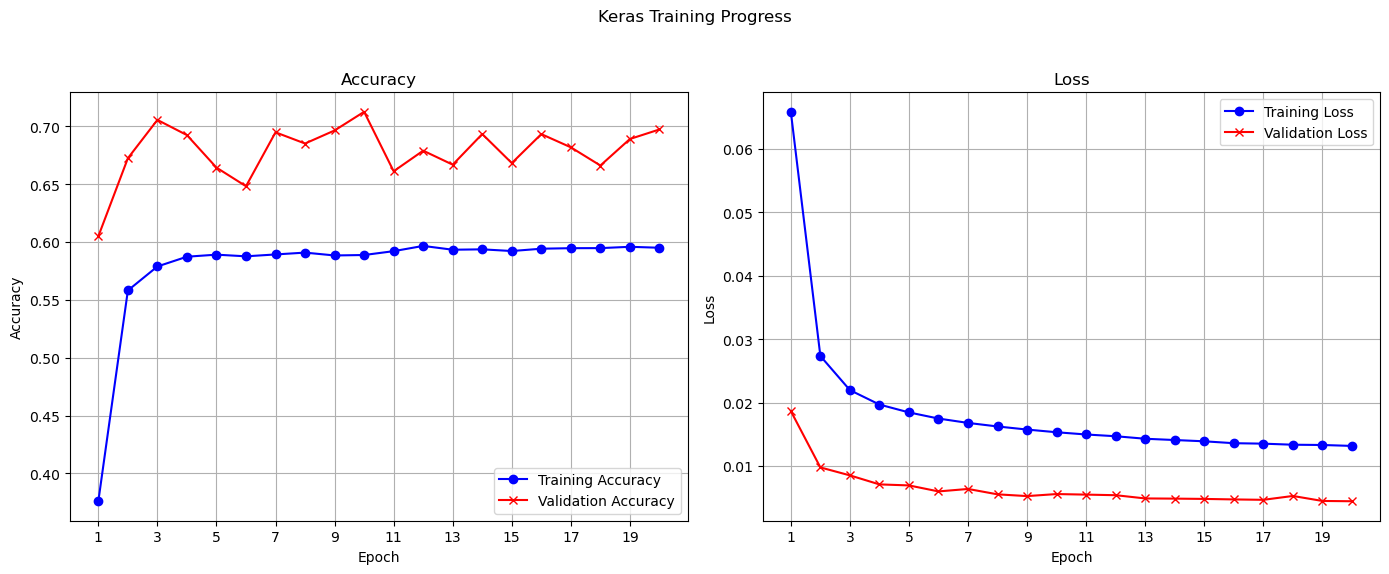

8604/8604 ━━━━━━━━━━━━━━━━━━━━ 441s 51ms/step - accuracy: 0.5971 - loss: 0.0132 - val_accuracy: 0.6973 - val_loss: 0.0044
Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 10.
Training finished. Final plot above.
Model weights saved successfully!


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint,Callback
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import os
import glob # To list files
import time
from IPython.display import clear_output
# --- Essential for GPU memory management ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        print("Mixed precision policy set to 'mixed_float16'.")

        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True) # Corrected
        print("Memory growth enabled for GPUs.")
    except RuntimeError as e:
        print(f"Error configuring GPU: {e}")
# ---------------------------------------------------------------------------------

print(f"TensorFlow version: {tf.__version__}")

# --- Configuration (using values from serialization part) ---
image_height = 256
image_width = 312
num_channels = 1
num_classes = 89
INPUT_SHAPE = (image_height, image_width, num_channels)
OUTPUT_DIM = num_classes
LEARNING_RATE = 0.001
BATCH_SIZE = 16 # Adjust as needed
EPOCHS = 100

# Directories where slices were saved
input_data_dir = 'data_slices/input'
output_data_dir = 'data_slices/output'

# --- Custom Callback for Live Loss Plotting (remains the same) ---
class JupyterLivePlottingCallback(Callback):
    def __init__(self, fig_title="Training Metrics"):
        super().__init__()
        self.fig_title = fig_title
        self.epoch_data = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
        self.epochs = []

    def on_train_begin(self, logs=None):
        # Initialize lists to store metrics
        self.epoch_data = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
        self.epochs = []
        print("Starting Keras model training with live plot. Output will update below...")

    def on_epoch_end(self, epoch, logs=None):
        # Clear the previous output in the cell
        clear_output(wait=True) # wait=True prevents flickering

        # Collect data for the current epoch
        self.epochs.append(epoch + 1) # Epochs are 0-indexed internally, make them 1-indexed for plot
        self.epoch_data['loss'].append(logs.get('loss'))
        self.epoch_data['accuracy'].append(logs.get('accuracy'))
        self.epoch_data['val_loss'].append(logs.get('val_loss'))
        self.epoch_data['val_accuracy'].append(logs.get('val_accuracy'))

        # Create a new figure and subplots for the updated plot
        fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(14, 6))
        fig.suptitle(self.fig_title)

        # Plot Accuracy
        ax_acc.plot(self.epochs, self.epoch_data['accuracy'], 'b-o', label='Training Accuracy')
        ax_acc.plot(self.epochs, self.epoch_data['val_accuracy'], 'r-x', label='Validation Accuracy')
        ax_acc.set_title('Accuracy')
        ax_acc.set_xlabel('Epoch')
        ax_acc.set_ylabel('Accuracy')
        ax_acc.grid(True)
        ax_acc.legend(loc='lower right')
        ax_acc.set_xticks(self.epochs if len(self.epochs) < 15 else self.epochs[::2]) # Show fewer ticks if many epochs

        # Plot Loss
        ax_loss.plot(self.epochs, self.epoch_data['loss'], 'b-o', label='Training Loss')
        ax_loss.plot(self.epochs, self.epoch_data['val_loss'], 'r-x', label='Validation Loss')
        ax_loss.set_title('Loss')
        ax_loss.set_xlabel('Epoch')
        ax_loss.set_ylabel('Loss')
        ax_loss.grid(True)
        ax_loss.legend(loc='upper right')
        ax_loss.set_xticks(self.epochs if len(self.epochs) < 15 else self.epochs[::2]) # Show fewer ticks if many epochs


        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
        plt.show() # Display the plot in the Jupyter output

        # Optional: Add a small delay if updates are too fast and hard to follow
        # time.sleep(0.5)

    def on_train_end(self, logs=None):
        print("Training finished. Final plot above.")


# --- 1. Define the Pure CNN Model (remains the same) ---
def build_cnn_model(input_shape, output_dim):
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape, dtype=tf.float32))

    model.add(layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.SpatialDropout2D(0.2))
    model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

    model.add(layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.SpatialDropout2D(0.2))
    model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

    model.add(layers.Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.SpatialDropout2D(0.3))
    model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(output_dim, activation='sigmoid', dtype=tf.float32))

    return model

# --- 2. Compile the Model (remains the same) ---
cnn_model = build_cnn_model(INPUT_SHAPE, OUTPUT_DIM)
cnn_model.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

cnn_model.summary()

# --- 3. Data Loading and Preparation (Stream from Disk - .npy files) ---

# Get lists of all input and output file paths
input_filepaths = sorted(glob.glob(os.path.join(input_data_dir, '*.npy')))
output_filepaths = sorted(glob.glob(os.path.join(output_data_dir, '*.npy')))

total_samples_on_disk = len(input_filepaths)
if total_samples_on_disk == 0:
    print(f"ERROR: No .npy files found in {input_data_dir}. Please run the serialization script first.")
    exit()
if total_samples_on_disk != len(output_filepaths):
    print("ERROR: Mismatch in number of input and output files.")
    exit()

print(f"Found {total_samples_on_disk} files on disk.")


# Function to load a single image and its label from file paths
def load_sample_from_files(input_path_tensor, output_path_tensor):
    # Convert TensorFlow string tensors to Python strings
    input_path = input_path_tensor.numpy().decode('utf-8')
    output_path = output_path_tensor.numpy().decode('utf-8')

    # Load the NumPy arrays
    image = np.load(input_path).astype(np.float32).reshape(INPUT_SHAPE)
    
    label = np.load(output_path).astype(np.float32).reshape(OUTPUT_DIM)

    # Ensure the image has the correct shape (H, W, C)
    image = tf.ensure_shape(image, INPUT_SHAPE)
    label = tf.ensure_shape(label, (OUTPUT_DIM,)) # Ensure label shape is correct

    return image, label


def tf_load_sample_from_files(ipath, opath):
    image, label = tf.py_function(
        load_sample_from_files, [ipath, opath], [tf.float32, tf.float32]
    )
    # Explicitly set shapes here!
    image.set_shape(INPUT_SHAPE)
    label.set_shape((OUTPUT_DIM,))
    return image, label
# Create a dataset from the lists of file paths
# These lists of paths are small enough to be held in RAM.
dataset = tf.data.Dataset.from_tensor_slices((input_filepaths, output_filepaths))

# Shuffle the list of paths first
dataset = dataset.shuffle(buffer_size=total_samples_on_disk) # Buffer size for shuffling paths

# Split the dataset into training and validation subsets based on indices
split_ratio = 0.7
num_train = int(total_samples_on_disk * split_ratio)

train_dataset = dataset.take(num_train)
val_dataset = dataset.skip(num_train)

# Map the loading function to the datasets using tf.py_function
# This function will load data from disk for each sample as it's needed
train_dataset = train_dataset.map(
    tf_load_sample_from_files,
    num_parallel_calls=tf.data.AUTOTUNE # Load in parallel threads/processes
)
val_dataset = val_dataset.map(
    tf_load_sample_from_files,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Apply batching and prefetching
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

plot_callback = PlotLoss()

# 3. Configure EarlyStopping callback to monitor val_accuracy
early_stopping_acc = EarlyStopping(
    monitor='val_accuracy', # Now monitoring validation accuracy
    patience=10,            # Number of epochs with no improvement
    mode='max',             # 'max' because we want to maximize accuracy
    verbose=1,              # Log when training stops
    restore_best_weights=True # Restore weights from the epoch with the best monitored value.
)

# Optional: Save the best model weights based on val_accuracy
model_checkpoint_acc = ModelCheckpoint(
    'best_model_by_acc.keras', # A different filename
    monitor='val_accuracy',
    mode='max',
    save_best_only=True, # Only save when validation accuracy improves
    verbose=1
)

jupyter_live_plot = JupyterLivePlottingCallback(fig_title="Keras Training Progress")
# --- 4. Training the Model ---
print("\n--- Training Pure CNN Model ---")
try:
    history_cnn = cnn_model.fit(train_dataset,
                                epochs=EPOCHS,
                                validation_data=val_dataset,
                                callbacks=[model_checkpoint_acc,early_stopping_acc,jupyter_live_plot])
    cnn_model.save_weights('guitarmidi.weights.h5')
    print("Model weights saved successfully!")
except Exception as e:
    print(f"An error occurred during training: {e}")